# 01 — Exploratory Data Analysis: APTOS 2019

Builds the canonical train/val/test split used by the whole project and profiles the raw
fundus images: file integrity, resolution, illumination, retinal-field border, and class balance.

**Produces**
- `data/splits/aptos_seed42.csv` — canonical 70/15/15 split, created once and reused everywhere.
- `data/eda/eda_image_report.csv` — per-image scan (cached; the slow step runs only once).
- `studies/01_eda/figures/*.png` — figures for the report.

Run top-to-bottom once to (re)generate outputs. Data and environment setup are in §0.
A pinned `requirements.txt` is listed in the appendix.

## 0. Setup

**Environment.** Python 3.11. From the repository root:

```
pip install -r requirements.txt
```

**Data.** APTOS 2019 is not redistributed here (Kaggle licence). Download
`aptos2019-blindness-detection` from Kaggle and lay it out as:

```
aptos2019/
    dataset.csv      # columns: id_code, diagnosis   (Kaggle ships this as train.csv — rename)
    images/          # <id_code>.png
```

In [1]:
# Version record for reproducibility. scikit-learn matters most: train_test_split
# stratification order can change across versions, so we pin it and also cache the split.
import sys, platform
import numpy as np, pandas as pd, cv2, sklearn, matplotlib, seaborn as sns

print("python      ", platform.python_version())
for m in (np, pd, cv2, sklearn, matplotlib, sns):
    print(f"{m.__name__:<12}", m.__version__)

python       3.11.15
numpy        2.4.4
pandas       3.0.3
cv2          5.0.0
sklearn      1.9.0
matplotlib   3.11.0
seaborn      0.13.2


In [2]:
from pathlib import Path

# --- Data (see §0) ---
DATA_DIR   = Path("aptos2019")
LABELS_CSV = DATA_DIR / "dataset.csv"
IMAGE_DIR  = DATA_DIR / "images"
ID_COL, LABEL_COL, IMG_EXT = "id_code", "diagnosis", ".png"

# --- Artifacts ---
SPLIT_CSV  = Path("data/splits/aptos_seed42.csv")
REPORT_CSV = Path("data/eda/eda_image_report.csv")
FIG_DIR    = Path("studies/01_eda/figures")
for d in (SPLIT_CSV.parent, REPORT_CSV.parent, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

SEED = 42
CLASS_NAMES = ["No DR", "Mild", "Moderate", "Severe", "Proliferative"]

assert LABELS_CSV.exists(), f"Missing {LABELS_CSV} — see setup in §0"
assert IMAGE_DIR.exists(),  f"Missing {IMAGE_DIR} — see setup in §0"

In [3]:
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

random.seed(SEED)
np.random.seed(SEED)
sns.set_style("whitegrid")

c:\Users\ritik\anaconda3\envs\cv-gpu\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Canonical split

70/15/15 stratified on the label, seed 42. Created once, cached to disk, and loaded by every
downstream notebook — so train/val/test membership is identical across the group and across
scikit-learn versions.

In [4]:
def make_split(labels_csv, seed=SEED):
    df = pd.read_csv(labels_csv)
    train, temp = train_test_split(df, test_size=0.30, stratify=df[LABEL_COL], random_state=seed)
    val,  test  = train_test_split(temp, test_size=0.50, stratify=temp[LABEL_COL], random_state=seed)
    parts = [train.assign(split="train"), val.assign(split="val"), test.assign(split="test")]
    return pd.concat(parts).sort_index().reset_index(drop=True)

if SPLIT_CSV.exists():
    split = pd.read_csv(SPLIT_CSV)
    print(f"Loaded cached split: {SPLIT_CSV}")
else:
    split = make_split(LABELS_CSV)
    split.to_csv(SPLIT_CSV, index=False)
    print(f"Created split -> {SPLIT_CSV}")

n = len(split)
counts = split["split"].value_counts().reindex(["train", "val", "test"])
print(counts.to_string())
print({k: f"{v / n:.1%}" for k, v in counts.items()})

Created split -> data\splits\aptos_seed42.csv
split
train    2563
val       549
test      550
{'train': '70.0%', 'val': '15.0%', 'test': '15.0%'}


**Split.** train 2,563 / val 549 / test 550 (70.0 / 15.0 / 15.0 %).

> APTOS 2019 ships no patient identifiers, so the split is necessarily image-level.
> Patient-level disjointness across splits cannot be verified; each image is treated as an
> independent capture. Recorded as a limitation in the report.

## 2. Class distribution

In [5]:
overall  = split[LABEL_COL].value_counts().sort_index()
by_split = (split.groupby("split")[LABEL_COL].value_counts()
                 .unstack(fill_value=0).reindex(["train", "val", "test"]))

dist = pd.DataFrame({"class": CLASS_NAMES,
                     "count": overall.values,
                     "pct":   (overall.values / n * 100).round(1)})
print(dist.to_string(index=False))
print(f"\nImbalance ratio (max:min) = {overall.max() / overall.min():.1f} : 1")

        class  count  pct
        No DR   1805 49.3
         Mild    370 10.1
     Moderate    999 27.3
       Severe    193  5.3
Proliferative    295  8.1

Imbalance ratio (max:min) = 9.4 : 1


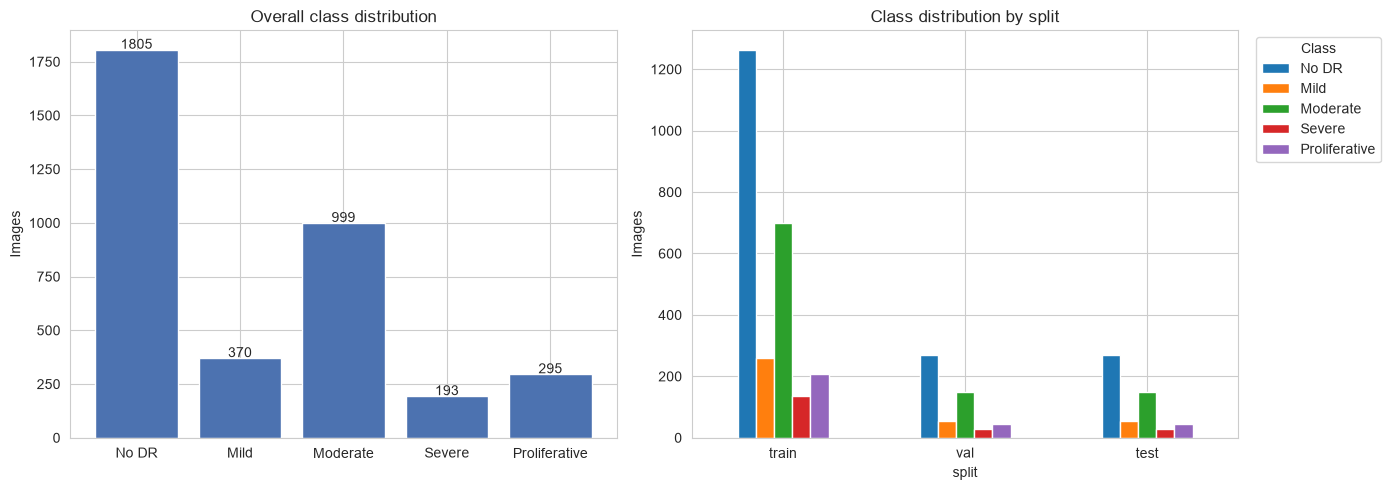

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].bar(CLASS_NAMES, overall.values, color="#4C72B0")
ax[0].set(title="Overall class distribution", ylabel="Images")
for i, v in enumerate(overall.values):
    ax[0].text(i, v + 5, str(v), ha="center")

by_split.rename(columns=dict(enumerate(CLASS_NAMES))).plot.bar(ax=ax[1])
ax[1].set(title="Class distribution by split", ylabel="Images")
ax[1].tick_params(axis="x", rotation=0)
ax[1].legend(title="Class", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.savefig(FIG_DIR / "class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

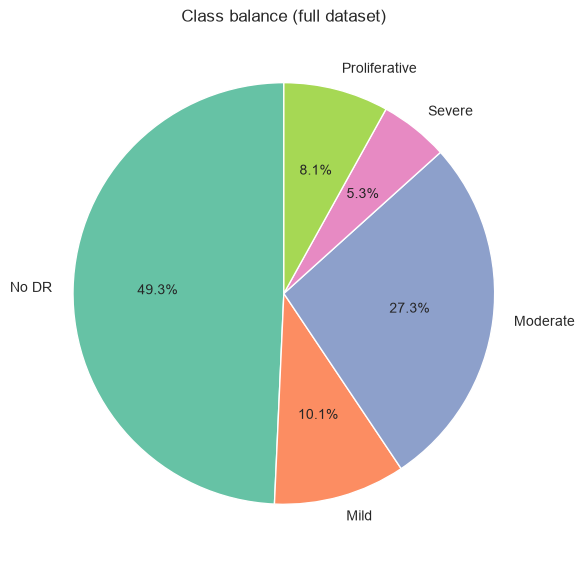

In [7]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(overall.values, labels=CLASS_NAMES, autopct="%1.1f%%",
       colors=sns.color_palette("Set2"), startangle=90)
ax.set_title("Class balance (full dataset)")
plt.tight_layout()
plt.savefig(FIG_DIR / "class_balance_pie.png", dpi=150)
plt.show()

**Class balance.** Strong imbalance — No DR 1,805 (49.3%), Moderate 999 (27.3%), Mild 370 (10.1%),
Proliferative 295 (8.1%), Severe 193 (5.3%); max:min ≈ **9.4 : 1**. Proportions hold across the
three splits, confirming stratification. This drives the imbalance experiments in later stages and
the choice of minority-sensitive metrics (QWK, macro-F1, per-class recall).

## 3. Image-level scan

One pass over every image: integrity, resolution, illumination (brightness/contrast proxies), and
the border a rectangular crop of the retinal disc would remove. The pass is slow (~12 min for 3,662
images), so the result is cached — subsequent runs load the CSV.

In [8]:
def crop_retinal_field(img_rgb, threshold=7):
    """Bounding box of the illuminated disc (pixels brighter than `threshold`)."""
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    mask = gray > threshold
    if not mask.any():
        return img_rgb
    ys, xs = np.where(mask)
    return img_rgb[ys.min():ys.max() + 1, xs.min():xs.max() + 1]

def scan_images(split_df):
    rows, missing, unreadable = [], [], []
    for r in tqdm(split_df.itertuples(index=False), total=len(split_df), desc="scan"):
        path = IMAGE_DIR / f"{getattr(r, ID_COL)}{IMG_EXT}"
        if not path.exists():
            missing.append(path); continue
        bgr = cv2.imread(str(path))
        if bgr is None:
            unreadable.append(path); continue
        rgb  = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
        h, w = gray.shape
        ch, cw = crop_retinal_field(rgb).shape[:2]
        rows.append({
            ID_COL: getattr(r, ID_COL), LABEL_COL: getattr(r, LABEL_COL), "split": r.split,
            "height": h, "width": w, "aspect_ratio": w / h,
            "brightness_mean": float(gray.mean()), "contrast_std": float(gray.std()),
            # Border a tight *rectangular* crop of the disc removes (the corner slack),
            # NOT the full dark-pixel area of the circular field. Named accordingly.
            "border_crop_frac": 1.0 - (ch * cw) / (h * w),
        })
    return pd.DataFrame(rows), missing, unreadable

if REPORT_CSV.exists():
    eda = pd.read_csv(REPORT_CSV)
    print(f"Loaded cached scan: {REPORT_CSV}  ({len(eda)} rows)")
else:
    eda, missing, unreadable = scan_images(split)
    eda.to_csv(REPORT_CSV, index=False)
    print(f"Scanned {len(eda)} images -> {REPORT_CSV}")
    print(f"Missing: {len(missing)}   Unreadable: {len(unreadable)}")

scan: 100%|██████████| 3662/3662 [07:42<00:00,  7.92it/s]

Scanned 3662 images -> data\eda\eda_image_report.csv
Missing: 0   Unreadable: 0


In [9]:
eda[["height", "width", "aspect_ratio",
     "brightness_mean", "contrast_std", "border_crop_frac"]].describe().round(2)

,height,width,aspect_ratio,brightness_mean,contrast_std,border_crop_frac
count,3662.00,3662.00,3662.00,3662.00,3662.00,3662.00
mean,1526.83,2015.18,1.28,66.79,38.81,0.09
std,542.66,884.30,0.18,17.98,9.74,0.12
min,358.00,474.00,1.00,14.97,9.61,0.00
25%,1050.00,1050.00,1.00,52.07,31.65,0.00
50%,1536.00,2144.00,1.33,68.97,40.13,0.06
75%,1958.00,2588.00,1.39,80.84,45.41,0.16
max,2848.00,4288.00,1.51,129.62,75.85,0.40


**Integrity & profile.** 3,662 images, 0 missing, 0 unreadable → no exclusions; the split covers
the full dataset. Resolutions span 358×474 to 2848×4288; illumination varies widely (brightness
66.8 ± 18.0, contrast 38.8 ± 9.7).

## 4. Resolution distribution

17 distinct resolutions; top: 1050x1050 (974 images)


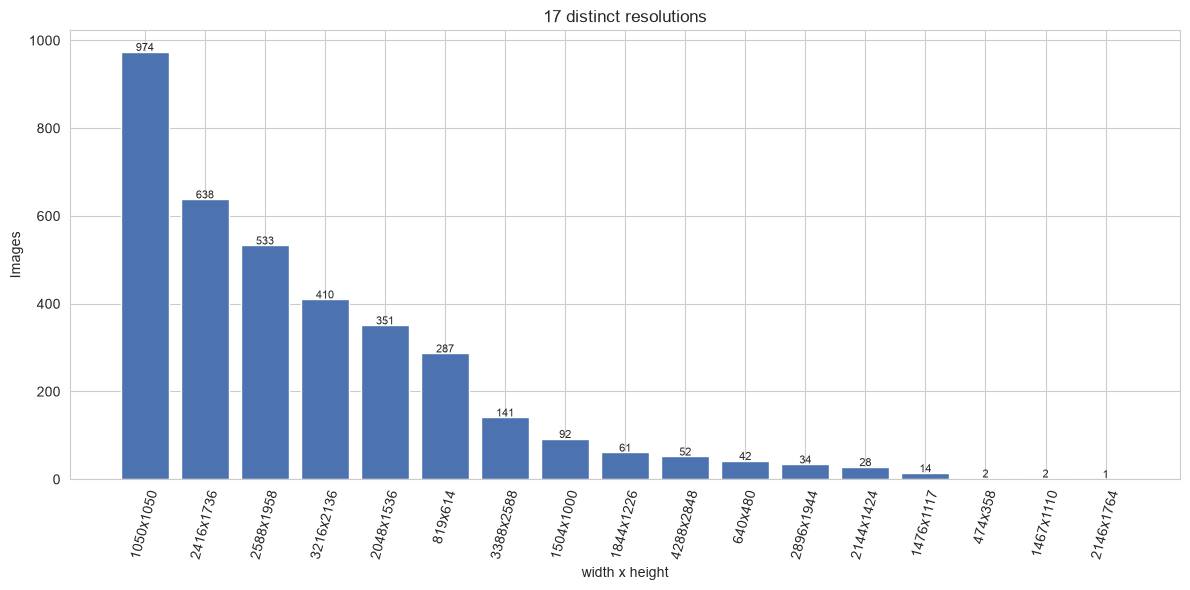

In [10]:
res = (eda["width"].astype(str) + "x" + eda["height"].astype(str)).value_counts()
print(f"{res.size} distinct resolutions; top: {res.index[0]} ({res.iloc[0]} images)")

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(res.index, res.values, color="#4C72B0")
ax.set(title=f"{res.size} distinct resolutions", xlabel="width x height", ylabel="Images")
ax.tick_params(axis="x", rotation=75)
for i, v in enumerate(res.values):
    ax.text(i, v + 2, str(v), ha="center", fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "resolution_bar.png", dpi=150)
plt.show()

**Resolution.** 17 distinct sizes; 1050×1050 dominates (974 images, ~27%). Heterogeneous input →
resize to a fixed size (224×224) before training.

## 5. Illumination as a confounder

If brightness or contrast separated the classes, the network could grade on lighting instead of
pathology (shortcut learning). Checked here before committing to preprocessing.

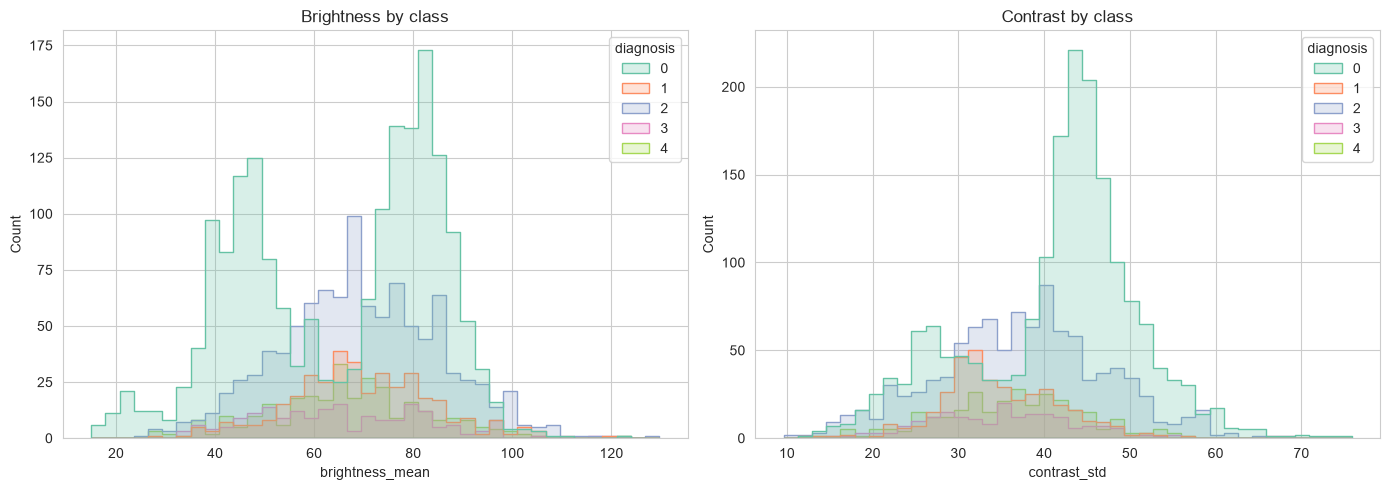

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for col, a, title in [("brightness_mean", ax[0], "Brightness by class"),
                      ("contrast_std",    ax[1], "Contrast by class")]:
    sns.histplot(eda, x=col, hue=LABEL_COL, palette="Set2", bins=40, element="step", ax=a)
    a.set_title(title)
plt.tight_layout()
plt.savefig(FIG_DIR / "brightness_contrast_by_class.png", dpi=150)
plt.show()

**Confounder check.** Brightness and contrast overlap heavily across all five classes — no global
illumination signal the model could exploit as a shortcut. No per-class photometric correction
needed; standard ImageNet normalisation is sufficient downstream.

## 6. Retinal-field border

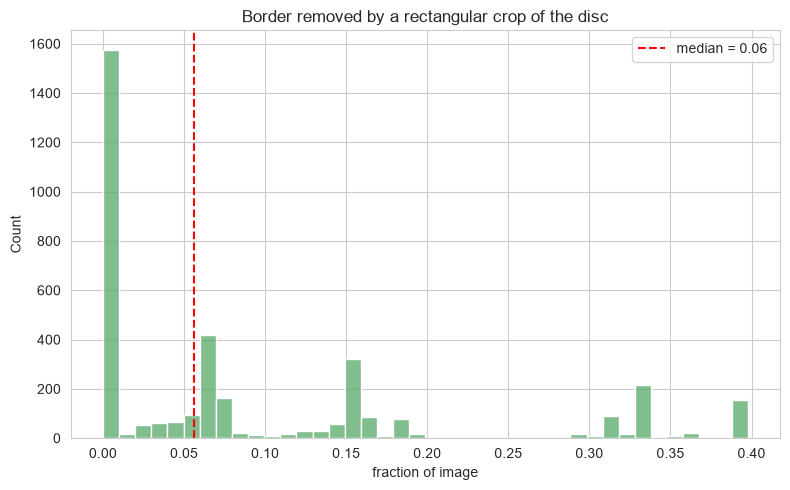

In [12]:
med = eda["border_crop_frac"].median()
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(eda["border_crop_frac"], bins=40, color="#55A868", ax=ax)
ax.axvline(med, color="red", ls="--", label=f"median = {med:.2f}")
ax.set(title="Border removed by a rectangular crop of the disc", xlabel="fraction of image")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "border_crop_fraction.png", dpi=150)
plt.show()

**Border.** A tight rectangular crop removes ~9% of the frame on average, with a long right tail.
Justifies cropping the field before resize so the network isn't fed dead border. This is the
bounding-box corner fraction, not the full dark area of the circular field (which is larger).

## 7. Brightness vs. contrast (outliers)

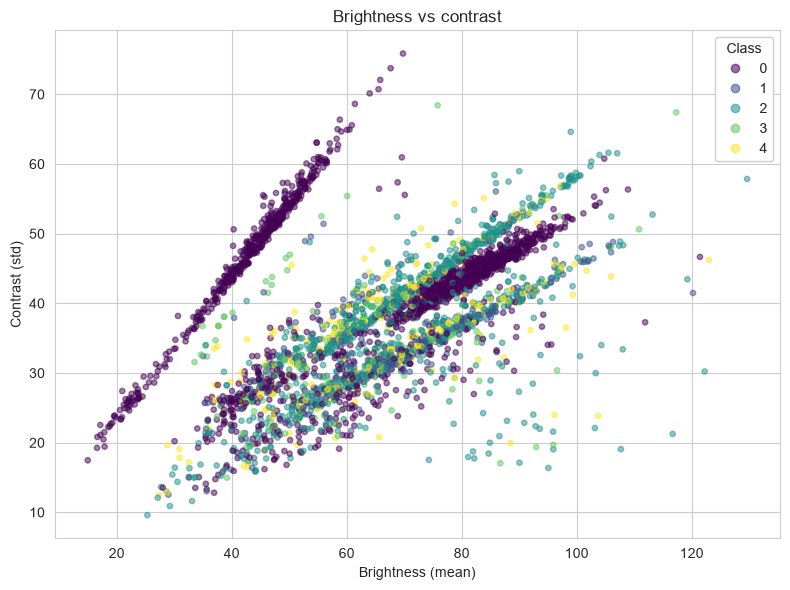

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(eda["brightness_mean"], eda["contrast_std"],
                c=eda[LABEL_COL], cmap="viridis", alpha=0.5, s=15)
ax.add_artist(ax.legend(*sc.legend_elements(), title="Class"))
ax.set(xlabel="Brightness (mean)", ylabel="Contrast (std)", title="Brightness vs contrast")
plt.tight_layout()
plt.savefig(FIG_DIR / "brightness_vs_contrast.png", dpi=150)
plt.show()

**Outliers.** No class-separated clusters. A few low-brightness / low-contrast points sit off the
main mass — quality candidates for manual review, though none were unreadable.

## 8. Sample images per class

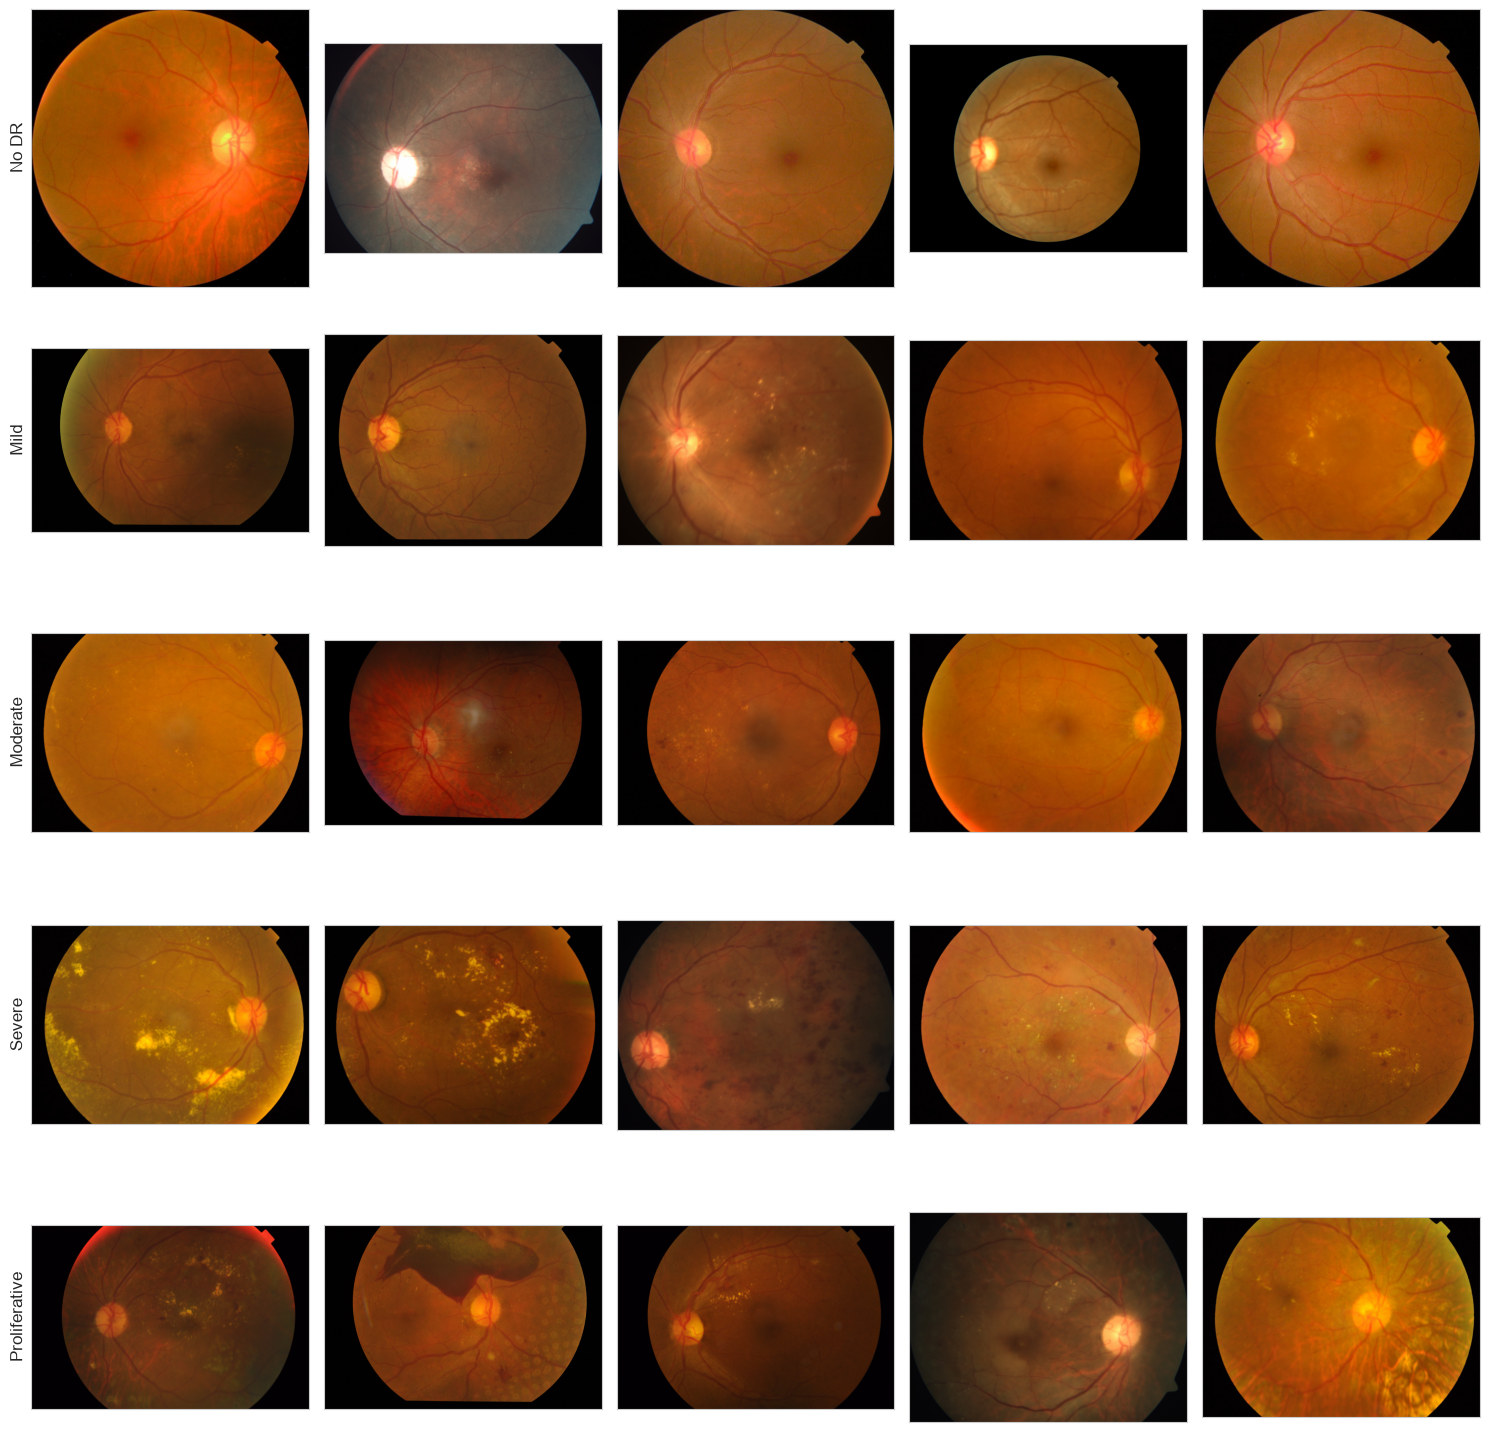

In [14]:
fig, axes = plt.subplots(5, 5, figsize=(15, 15))
for c in range(5):
    pool = split[(split[LABEL_COL] == c) & (split["split"] == "train")]
    sample = pool.sample(min(5, len(pool)), random_state=SEED)
    for j, row in enumerate(sample.itertuples(index=False)):
        rgb = cv2.cvtColor(cv2.imread(str(IMAGE_DIR / f"{getattr(row, ID_COL)}{IMG_EXT}")),
                           cv2.COLOR_BGR2RGB)
        axes[c, j].imshow(rgb)
    for j in range(5):
        axes[c, j].set_xticks([]); axes[c, j].set_yticks([])
    axes[c, 0].set_ylabel(CLASS_NAMES[c], fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / "samples_per_class.png", dpi=150)
plt.show()

**Samples.** Inter-grade differences are subtle (notably Mild vs Moderate), consistent with the
difficulty of fine-grained DR grading and with the imbalance-aware handling applied later.

## 9. EDA → design decisions

| Observation | Evidence | Decision downstream |
|---|---|---|
| Class imbalance ≈ 9.4 : 1 | §2 | Class-weighted loss / sampler; minority-sensitive metrics (QWK, macro-F1, per-class recall) |
| 17 resolutions, up to 4288 px | §3–4 | Resize to fixed 224×224 |
| ~9% removable border (bbox corner) | §3, §6 | Retinal-field crop before resize |
| Illumination overlaps across classes | §5, §7 | No lighting shortcut; ImageNet normalisation, no per-class correction |
| 0 missing / unreadable | §3 | No exclusions; split covers all 3,662 images |

The split (`data/splits/aptos_seed42.csv`) and scan (`data/eda/eda_image_report.csv`) are the
artifacts consumed by the preprocessing and modelling stages.

## Appendix — requirements.txt

Save at the repository root; install with `pip install -r requirements.txt`.

```
numpy==1.26.4
pandas==2.2.2
opencv-python-headless==4.10.0.84
scikit-learn==1.4.2
matplotlib==3.8.4
seaborn==0.13.2
tqdm==4.66.4
pyyaml==6.0.1
```

scikit-learn is pinned because `train_test_split` stratification order can differ across versions.
The cached split file is the authoritative artifact regardless of environment.